In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


def save_biased_results_csv(
    csv_path,
    dataset_name,
    model_arch,
    estimator_name,
    y_true,
    y_pred,
    ndcg5=None,
    ndcg10=None,
    recall5=None,
    recall10=None,
):
    """Save biased evaluation metrics for one model into a CSV.

    Columns: Dataset, Architecture, Model, MSE, RMSE, MAE, NDCG@5, NDCG@10, Recall@5, Recall@10.
    """
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))

    row = {
        "Dataset": dataset_name,
        "Architecture": model_arch,
        "Model": estimator_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "NDCG@5": np.nan if ndcg5 is None else float(ndcg5),
        "NDCG@10": np.nan if ndcg10 is None else float(ndcg10),
        "Recall@5": np.nan if recall5 is None else float(recall5),
        "Recall@10": np.nan if recall10 is None else float(recall10),
    }

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])

    df.to_csv(csv_path, index=False)
    print(f"Saved biased results to: {csv_path}")


def compute_and_save_biased_results_ncf_coat():
    """Compute Naive ERM metrics on biased Coat NCF split and save to CSV.

    Run this AFTER training, when `model`, `X_test`, and `y_test` are defined.
    """
    y_pred = model.predict(X_test, verbose=0).flatten()
    csv_path = "biased_results_coat_ncf.csv"
    return save_biased_results_csv(
        csv_path=csv_path,
        dataset_name="COAT",
        model_arch="NCF",
        estimator_name="Naive ERM",
        y_true=y_test,
        y_pred=y_pred,
    )


# NCF Model for Coat Shopping Dataset
## Neural Collaborative Filtering for Recommendation System

This notebook implements the NCF model on the Coat Shopping dataset.


In [17]:
# =========
# Load file
# =========
import pandas as pd
import numpy as np

# Load the combined Coat dataset (train + test combined)
# Path is relative to this notebook: ../../data/coat_data/coat_data/coat/coat_combined.csv

data_file = '../../data/coat_data/coat_data/coat/coat_combined.csv'

# Load the data
ratings = pd.read_csv(data_file)

print("Data loaded successfully!")
print(f"Total interactions: {len(ratings)}")
print(f"Columns: {ratings.columns.tolist()}")


Data loaded successfully!
Total interactions: 11600
Columns: ['userId', 'itemId', 'rating']


In [18]:
# =========
# Data info
# =========
print("Dataset shape:", ratings.shape)
print("\nFirst few rows:")
print(ratings.head(10))

print("\nData types:")
print(ratings.dtypes)

print("\nBasic statistics:")
print(ratings.describe())

print("\n" + "="*50)
print("Dataset Summary:")
print("="*50)
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print(f"Total interactions: {len(ratings)}")

print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

# Average ratings
user_avg = ratings.groupby('userId')['rating'].mean()
item_avg = ratings.groupby('itemId')['rating'].mean()

print(f"\nAverage rating per user: {user_avg.mean():.3f}")
print(f"Average rating per item: {item_avg.mean():.3f}")

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
print(f"\nAverage interactions per user: {ratings_per_user.mean():.2f}")
print(f"Min interactions per user: {ratings_per_user.min()}")
print(f"Max interactions per user: {ratings_per_user.max()}")

# Ratings per item
ratings_per_item = ratings.groupby('itemId')['rating'].count()
print(f"\nAverage interactions per item: {ratings_per_item.mean():.2f}")
print(f"Min interactions per item: {ratings_per_item.min()}")
print(f"Max interactions per item: {ratings_per_item.max()}")


Dataset shape: (11600, 3)

First few rows:
   userId  itemId  rating
0       0      72     2.0
1       0     136     2.0
2       0     150     3.0
3       0     171     3.0
4       0     188     3.0
5       0     220     3.0
6       0     227     5.0
7       0     228     4.0
8       0     234     3.0
9       0     235     4.0

Data types:
userId      int64
itemId      int64
rating    float64
dtype: object

Basic statistics:
           userId        itemId        rating
count  11600.0000  11600.000000  11600.000000
mean     144.5000    150.526638      2.458448
std       83.7189     84.604770      1.292139
min        0.0000      0.000000      1.000000
25%       72.0000     85.000000      1.000000
50%      144.5000    142.000000      2.000000
75%      217.0000    229.000000      3.000000
max      289.0000    299.000000      5.000000

Dataset Summary:
Unique users: 290
Unique items: 300
Total interactions: 11600

Rating distribution:
rating
1.0    3780
2.0    2336
3.0    2719
4.0    1916


In [19]:
# =============
# Preprocessing
# =============
from sklearn.preprocessing import MinMaxScaler

# Filter items with minimum number of ratings (to remove very sparse items)
min_item_ratings = 1  # Coat dataset is smaller, so we use lower threshold
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings to 0-1 range
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create user and item encodings (map to continuous indices starting from 0)
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

# Apply encoding
ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

# Get dimensions
num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")

# Convert ratings to float32 for better performance
ratings['rating'] = ratings['rating'].values.astype(np.float32)

print("\nPreprocessing complete!")
print(ratings.head())


After filtering items with < 1 ratings:
Remaining interactions: 11600
Unique users: 290
Unique items: 300

Encoded dataset:
Number of users: 290
Number of items: 300

Preprocessing complete!
   userId  itemId  rating  user  item
0       0      72    0.25     0     0
1       0     136    0.25     0     1
2       0     150    0.50     0     2
3       0     171    0.50     0     3
4       0     188    0.50     0     4


In [20]:
# =============================
# User-wise Train-Test split
# =============================
# This ensures each user has representation in both train and test sets

train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    
    # Shuffle user's data
    user_data = user_data.sample(frac=1, random_state=42)
    
    # 80-20 split, but ensure at least 1 sample in each set
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train %: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}%")
print(f"Test %: {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")


Train-Test split complete!
Train shape: (9280, 5)
Test shape: (2320, 5)
Train %: 80.0%
Test %: 20.0%


In [21]:
# ============================
# Prepare Train/Test Arrays
# ============================
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]

y_train = train_df['rating'].values
y_test = test_df['rating'].values

print("Training data prepared!")
print(f"X_train users shape: {X_train[0].shape}")
print(f"X_train items shape: {X_train[1].shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nTest data prepared!")
print(f"X_test users shape: {X_test[0].shape}")
print(f"X_test items shape: {X_test[1].shape}")
print(f"y_test shape: {y_test.shape}")


Training data prepared!
X_train users shape: (9280,)
X_train items shape: (9280,)
y_train shape: (9280,)

Test data prepared!
X_test users shape: (2320,)
X_test items shape: (2320,)
y_test shape: (2320,)


In [22]:
# ===============
# Define NCF Model
# ===============
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.models import Model

# Hyperparameters
embedding_size = 32

# Input layers
user_input = Input(shape=(1,), name="user_input")
item_input = Input(shape=(1,), name="item_input")

# Embedding layers
user_embedding = Embedding(num_users, embedding_size, embeddings_initializer="he_normal", name="user_embedding")(user_input)
item_embedding = Embedding(num_items, embedding_size, embeddings_initializer="he_normal", name="item_embedding")(item_input)

# Flatten embeddings
user_vec = Flatten()(user_embedding)
item_vec = Flatten()(item_embedding)

# Concatenate user and item vectors
concat = Concatenate()([user_vec, item_vec])

# Deep neural network layers
dense = Dense(256, activation='relu')(concat)
dense = BatchNormalization()(dense)
dense = Dropout(0.5)(dense)

dense = Dense(128, activation='relu')(dense)
dense = BatchNormalization()(dense)
dense = Dropout(0.4)(dense)

dense = Dense(64, activation='relu')(dense)
dense = BatchNormalization()(dense)

# Output layer (sigmoid for 0-1 normalized ratings)
output = Dense(1, activation='sigmoid', name="output")(dense)

# Create model
model = Model(inputs=[user_input, item_input], outputs=output)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model architecture:")
model.summary()


Model architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │      9,600 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     16,640 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,529 (306.75 KB)

 Trainable params: 77,633 (303.25 KB)

 Non-trainable params: 896 (3.50 KB)

In [23]:
# ==============
# Train Model
# ==============

# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("C:/Users/prana/OneDrive/Documents/thesis/pranathi3/biased data/coat shopping/ncf_coat_best_model.keras", save_best_only=True)
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1455 - mae: 0.3169 - val_loss: 0.1083 - val_mae: 0.2860
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1136 - mae: 0.2835 - val_loss: 0.1063 - val_mae: 0.2858
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1039 - mae: 0.2696 - val_loss: 0.1065 - val_mae: 0.2850
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0966 - mae: 0.2594 - val_loss: 0.1074 - val_mae: 0.2838
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0894 - mae: 0.2480 - val_loss: 0.1057 - val_mae: 0.2810
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0850 - mae: 0.2398 - val_loss: 0.1017 - val_mae: 0.2773
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0793 - mae: 0.2300 - val_loss: 0.1024 - val_mae: 0.2737
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0754 - mae: 0.2233 - val_loss: 0.0966 - val_mae: 0.2685
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.073

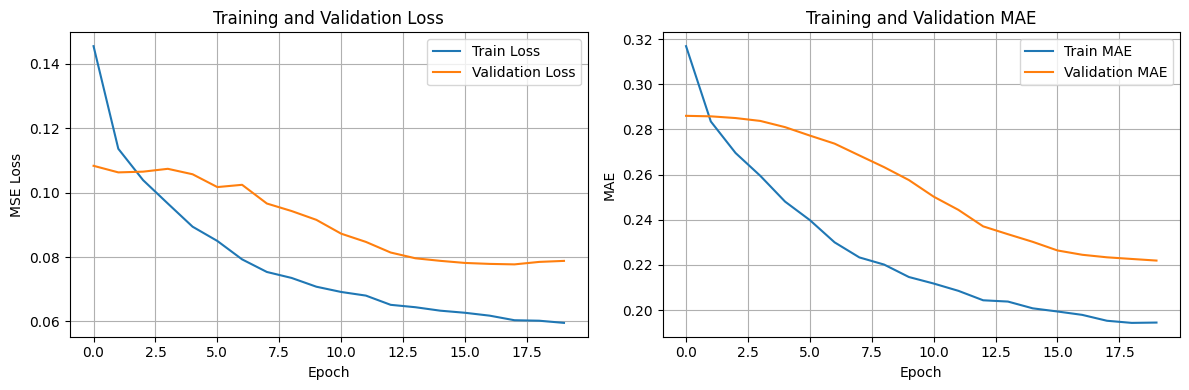

In [24]:
# ====================
# Plot Training History
# ====================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [25]:
# ===========================
# Evaluate on Test Data
# ===========================
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

y_pred = model.predict(X_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*50)

# Save metrics to file
metrics_text = (
    f"NCF Model Evaluation - Coat Shopping Dataset\n"
    f"=====================================\n"
    f"Test Loss (MSE): {test_loss:.4f}\n"
    f"Test MAE: {test_mae:.4f}\n"
    f"Test RMSE: {rmse:.4f}\n"
    f"\n"
    f"Dataset Info:\n"
    f"- Total users: {num_users}\n"
    f"- Total items: {num_items}\n"
    f"- Training samples: {len(train_df)}\n"
    f"- Test samples: {len(test_df)}\n"
)

with open("../results/metrics_coat.txt", "w") as f:
    f.write(metrics_text)

print("\nMetrics saved to: ../results/metrics_coat.txt")


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0777 - mae: 0.2233

MODEL EVALUATION METRICS
Test Loss (MSE): 0.0777
Test MAE: 0.2233
Test RMSE: 0.2788

Metrics saved to: ../results/metrics_coat.txt


In [26]:
# ===============
# Recommender Function
# ===============
def recommend_items(user_id_original, model, user2user_encoded, item2item_encoded, 
                   itemencoded2item, train_df, num_items, top_n=10):
    """
    Recommend top N items for a given user
    
    Args:
        user_id_original: Original user ID from the dataset
        model: Trained NCF model
        user2user_encoded: Dictionary mapping original user IDs to encoded IDs
        item2item_encoded: Dictionary mapping original item IDs to encoded IDs
        itemencoded2item: Dictionary mapping encoded IDs to original item IDs
        train_df: Training dataframe
        num_items: Total number of items
        top_n: Number of recommendations to return
    
    Returns:
        List of recommended item IDs with predicted ratings
    """
    # Check if user exists
    if user_id_original not in user2user_encoded:
        print(f"User {user_id_original} not found in the dataset!")
        return []
    
    # Encode user
    user_enc = user2user_encoded[user_id_original]
    
    # All encoded items
    all_item_ids = np.arange(num_items)
    
    # Items the user has already rated in training
    items_rated = train_df[train_df['user'] == user_enc]['item'].values
    
    # Candidate items (unseen by user)
    items_to_predict = np.setdiff1d(all_item_ids, items_rated)
    
    if len(items_to_predict) == 0:
        print(f"User {user_id_original} has already rated all items!")
        return []
    
    # Prepare input arrays
    user_array = np.full(len(items_to_predict), user_enc)
    
    # Predict scores
    preds = model.predict([user_array, items_to_predict], verbose=0).flatten()
    
    # Sort by predicted score
    top_indices = items_to_predict[np.argsort(preds)[::-1][:top_n]]
    top_scores = preds[np.argsort(preds)[::-1][:top_n]]
    
    # Map back to original item IDs
    recommendations = []
    for item_enc, score in zip(top_indices, top_scores):
        item_id_original = itemencoded2item[item_enc]
        # Convert score back to original scale
        score_original = scaler.inverse_transform([[score]])[0][0]
        recommendations.append((item_id_original, score, score_original))
    
    return recommendations

print("Recommender function defined!")


Recommender function defined!


In [27]:
# ===============================
# Generate Recommendations
# ===============================
# Let's get recommendations for a random user

# Pick a random user from the dataset
sample_user = np.random.choice(list(user2user_encoded.keys()))

print(f"Generating recommendations for User {sample_user}")
print("="*50)

# Get user's existing ratings from training set
user_enc = user2user_encoded[sample_user]
user_history = train_df[train_df['user'] == user_enc][['itemId', 'rating']].head(10)

print(f"\nUser {sample_user}'s rating history (sample):")
if len(user_history) > 0:
    for idx, row in user_history.iterrows():
        rating_original = scaler.inverse_transform([[row['rating']]])[0][0]
        print(f"  Item {row['itemId']}: Rating {rating_original:.2f}")
else:
    print("  No rating history in training set")

# Generate recommendations
recommendations = recommend_items(
    user_id_original=sample_user,
    model=model,
    user2user_encoded=user2user_encoded,
    item2item_encoded=item2item_encoded,
    itemencoded2item=itemencoded2item,
    train_df=train_df,
    num_items=num_items,
    top_n=10
)

print(f"\nTop 10 Recommended Items for User {sample_user}:")
print("="*50)
for i, (item_id, score_scaled, score_original) in enumerate(recommendations, 1):
    print(f"{i:2d}. Item {item_id:4d} | Predicted Rating: {score_original:.2f} (scaled: {score_scaled:.3f})")


Generating recommendations for User 64

User 64's rating history (sample):
  Item 283.0: Rating 1.00
  Item 262.0: Rating 3.00
  Item 254.0: Rating 1.00
  Item 71.0: Rating 2.00
  Item 173.0: Rating 4.00
  Item 235.0: Rating 4.00
  Item 260.0: Rating 4.00
  Item 81.0: Rating 1.00
  Item 281.0: Rating 3.00
  Item 179.0: Rating 1.00

Top 10 Recommended Items for User 64:
 1. Item  252 | Predicted Rating: 3.55 (scaled: 0.638)
 2. Item  121 | Predicted Rating: 3.50 (scaled: 0.626)
 3. Item  193 | Predicted Rating: 3.46 (scaled: 0.616)
 4. Item    0 | Predicted Rating: 3.40 (scaled: 0.600)
 5. Item  107 | Predicted Rating: 3.38 (scaled: 0.596)
 6. Item  118 | Predicted Rating: 3.35 (scaled: 0.589)
 7. Item   62 | Predicted Rating: 3.35 (scaled: 0.588)
 8. Item  120 | Predicted Rating: 3.34 (scaled: 0.584)
 9. Item  210 | Predicted Rating: 3.32 (scaled: 0.579)
10. Item  227 | Predicted Rating: 3.31 (scaled: 0.578)


In [28]:
# ===============================
# Model Summary and Information
# ===============================
print("\n" + "="*60)
print("NCF MODEL SUMMARY")
print("="*60)
print(f"Dataset: Coat Shopping Dataset")
print(f"Total Users: {num_users}")
print(f"Total Items: {num_items}")
print(f"Total Interactions: {len(ratings)}")
print(f"\nTraining Samples: {len(train_df)}")
print(f"Test Samples: {len(test_df)}")
print(f"\nEmbedding Size: {embedding_size}")
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*60)
print("\nModel saved as: ncf_coat_best_model.keras")
print("Metrics saved as: ../results/metrics_coat.txt")



NCF MODEL SUMMARY
Dataset: Coat Shopping Dataset
Total Users: 290
Total Items: 300
Total Interactions: 11600

Training Samples: 9280
Test Samples: 2320

Embedding Size: 32

Test MSE: 0.0777
Test MAE: 0.2233
Test RMSE: 0.2788

Model saved as: ncf_coat_best_model.keras
Metrics saved as: ../results/metrics_coat.txt
